PINN Example: One-dimensional Non-linear Schroedinger Equation
===


Summary:
---

---

This example is taken from Maziar Raissi's example [here](https://github.com/maziarraissi/PINNs/blob/master/main/continuous_time_inference%20(Schrodinger)/Schrodinger.py) which accompanies his original [work](https://www.sciencedirect.com/science/article/pii/S0021999118307125).

The [one-dimensional Schroedinger equation](https://en.wikipedia.org/wiki/Nonlinear_Schr%C3%B6dinger_equation) we consider in this example is:

$$
i \partial_t h = -\frac{1}{2} \partial_x^2 h  + \kappa | h |^2 h,
$$

where $\kappa = -1$, and periodic and Neumann boundary conditions are assumed such that:

$$
h (t, 5) = h (t, -5),
$$
$$
\partial_x h (t, 5) = \partial_x h (t, -5).
$$

The initial condition is:

$$
h (0, x) = 2 {\rm sech}(x).
$$

The bounds of the problem are constrained to: $t \in [0, \pi/2]$, $x \in [-5, 5]$.

Simulated data as ground-truth is provided [here](https://github.com/maziarraissi/PINNs/blob/1b3e90e82c47d49aee290aa481550f5e9c582d9a/main/Data/NLS.mat) and has been copied to `data/`. The PINN we are going to create looks something like this:

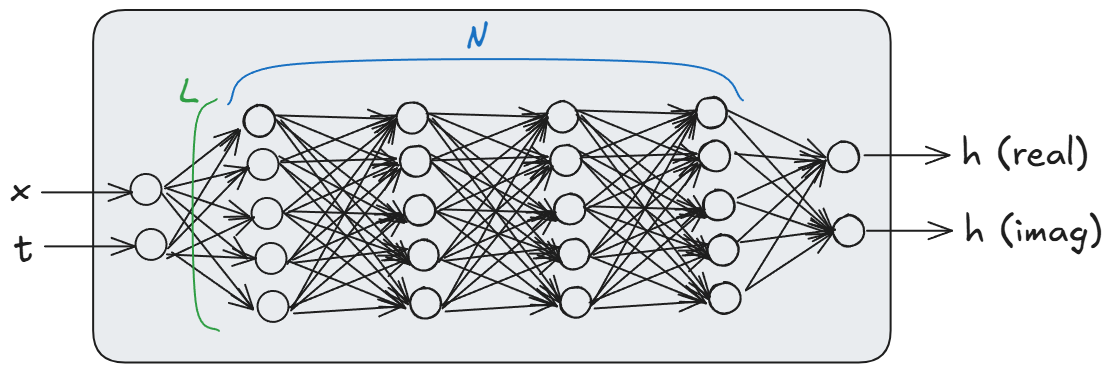

Key Points
---

---

* Here we have to predict a complex-valued target ($h$).  To do this, we simply turn the neural network into a multi-output model with 2 outputs: one for the real part and one for the complex part.  Care should be taken when applying the balance equations in the losses since real parts and imaginary parts need to be treated separately.

* Unlike Dirichlet BCs, when we have periodic BCs and/or Neumann BC's we need to evalue the BCs at the same time points between the upper and lower boundaries.  This symmetry is not required when we are simply testing that the field is a fixed, known value along a boundary.

⚠ In principle, training should be halted based on when the loss measured on a held-out validation set; this is not done here, though it is not difficult to implement.  For illustration purposes the approach used below is sufficient.

In [ ]:
import os
import plotly
import tqdm

os.environ["KERAS_BACKEND"] = "tensorflow"
import keras

import numpy as np
import plotly.graph_objects as go
import scipy.io as sio
import tensorflow as tf

from numpy.typing import NDArray
from plotly.subplots import make_subplots
from pyDOE import lhs
from typing import ClassVar, Any, Union

In [ ]:
%load_ext watermark
%watermark -t -m -v --iversions

# 1. Inference: Solving the PDE with IC and BCs

In [ ]:
# For reproducibility, let's set these seeds
np.random.seed(1234)
tf.random.set_seed(1234)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that
tf.config.experimental.enable_op_determinism()

## Create the ICs and BCs and choose collocation points

In [ ]:
# This data was simulated with kappa = -1
data = sio.loadmat('./data/NLS.mat')

# Extract data from file
t = data['tt'].reshape(-1, 1) # Time values h was measured at
x = data['x'].reshape(-1, 1) # X positions h was measured at
h = data['uu'] # h (field) measured on an (x, t) grid

N_0 = 50 # Number of initial condition points to use
N_b = 50 # Number of boundary points to use
N_f = 20000 # Number of measured h(x, t) training points to use

# Randomly select x positions at t = 0 to use during fitting
idx_x = np.random.choice(x.shape[0], N_0, replace=False)
x_0 = x[idx_x, :] # Take IC at these x positions
h_0 = h[idx_x, 0:1]

# Randomly select t points along boundaries
idx_t = np.random.choice(t.shape[0], N_b, replace=False)
t_b = t[idx_t, :] # Take BC at these t points

# Use latin-hypercube sampling to get a random sampling of (x, t) points
# we will predict / measure the fitted neural net against.
lb = np.array([-5.0, 0.0])
ub = np.array([5.0, np.pi/2])
X_f = lb + (ub-lb)*lhs(2, N_f) # "Interior" (x, t) points

X_lb = np.concatenate((0*t_b + lb[0], t_b), axis=1) # BC: (x=-5, t) points
X_ub = np.concatenate((0*t_b + ub[0], t_b), axis=1) # BC: (x=+5, t) points
X_0 = np.concatenate((x_0, 0*x_0), axis=1) # IC: (x_0, t=0) points

# We will visualize the results of the PINN on this grid later
X, T = np.meshgrid(x, t)
X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

In [ ]:
# Let's visualize the ground truth we conveniently have access to
fig = make_subplots(rows=1, cols=3,
                    specs=[[{'is_3d': True}, {'is_3d': True}, {'is_3d': True}]],
                    subplot_titles=['Real Component', 'Imaginary Component', 'Magnitude'],
                    )
fig.add_trace(go.Surface(z=np.real(h).T, x=x.flatten(), y=t.flatten()), 1, 1)
fig.add_trace(go.Surface(z=np.imag(h).T, x=x.flatten(), y=t.flatten()), 1, 2)
fig.add_trace(go.Surface(z=np.sqrt(np.imag(h).T**2 + np.real(h).T**2), x=x.flatten(), y=t.flatten()), 1, 3)
fig.update_layout(title=dict(text='Non-linear Schroedinger Equation (Simulated Ground Truth)'), autosize=True)
fig.update_scenes(
    dict(
        xaxis_title='x position',
        yaxis_title='time',
        zaxis_title='h(x, t)'
    )
)
fig.show()

## Solve

In [ ]:
import mlflow

# If you are not using the Docker devcontainer you might need to point to your MLFlow server
# The start_jupyter.sh automatically sets the MLFLOW_TRACKING_URI to match the start_mlflow.sh script
# mlflow.set_tracking_uri('http://127.0.0.1:4342') 

In [ ]:
class PINN_1DNLS:
    """
    Fit the solution to the non-linear Schroedinger equation.
    """
    kappa: ClassVar[Any]
    model: ClassVar[Any]
    layers: ClassVar[list[int]]
    activation: ClassVar[str]

    _X_0_x: ClassVar[tf.Variable]
    _X_0_t: ClassVar[tf.Variable]
    _u_0: ClassVar[tf.Variable]
    _v_0: ClassVar[tf.Variable]

    _X_ub_x: ClassVar[tf.Variable]
    _X_ub_t: ClassVar[tf.Variable]
    _X_lb_x: ClassVar[tf.Variable]
    _X_lb_t: ClassVar[tf.Variable]

    _X_f_x: ClassVar[tf.Variable]
    _X_f_t: ClassVar[tf.Variable]

    activation: ClassVar[str]
    mlflow_experiment: ClassVar[str]
    _dtype: ClassVar[str]
    model: ClassVar[Any]
    filename: ClassVar[str]

    def __init__(
        self,
        layers: list[int],
        kappa: float,
        X_0: NDArray[np.floating],
        h_0: NDArray[np.complexfloating],
        X_lb: NDArray[np.floating],
        X_ub: NDArray[np.floating],
        X_f: NDArray[np.floating],
        activation: str = 'tanh',
        experiment_name: Union[str, None] = 'intro-schroedinger-tf',
        dtype: str = 'float32'
    ) -> None:
        """
        Instantiate the network to make predictions.

        Parameters
        ----------
        layers : list(int)
            An ordered list of the size of each dense layer in the network to create.

        kappa : float
            Kappa value.

        X_0 : ndarray(float, ndim=2)
            Column of [x, t] positions to monitor the initial condition (IC) loss at.

        h_0 : ndarray(complex, ndim=2)
            Column of field values at each `X_0` point.

        X_lb : ndarray(float, ndim=2)
            Column of [x, t] positions to monitor the lower boundary conditions (BCs) loss at. For example, all x = -5 while t values can be chosen randomly. The `t` values should align with `X_ub` for these bounary conditions.

        X_ub : ndarray(float, ndim=2)
            Column of [x, t] positions to monitor the lower boundary conditions (BCs) loss at. For example, all x = +5 while t values can be chosen randomly. The `t` values should align with `X_lb` for these bounary conditions.

        X_f : ndarray(float, ndim=2)
            Column of [x, t] pairs corresponding to the points where consistency with PDE conservation will be assessed "inside" the domain.

        activation : str, optional(default='tanh')
            Activation function (by name) to use in each layer.

        experiment_name : str, optional(default='intro-schroedinger-tf')
            MLFlow experiment name; if your selected one exists, choose a new one.

        dtype : str, optional(default='float32')
            Precision to train neural net with.
        """
        # Set up a new experiment in MLFlow
        mlflow_experiment = mlflow.create_experiment(experiment_name)
        setattr(self, "mlflow_experiment", mlflow_experiment)

        # Sanity checks
        assert(X_0.ndim == 2), 'X_0 should be two-dimensional'
        assert(h_0.ndim == 2), 'h_0 should be a column'
        assert(len(h_0) == len(h_0)), 'h_0 and h_0 should have the same length'

        assert(X_lb.ndim == 2), 'X_lb should be two-dimensional'
        assert(X_ub.ndim == 2), 'X_ub should be two-dimensional'
        assert(np.all(X_lb[:, 1:2] == X_ub[:, 1:2])), 't values should align in X_ub and X_lb for these boundary conditions'

        assert(X_f.ndim == 2), 'X_f should be two-dimensional'

        # Set internal attributes and convert ndarray -> tf.Variable.
        # It is convenient to break up columns of X into [x, t] for when we need to take derivatives with respect to each of these individual variables.
        setattr(self, "layers", layers)
        setattr(self, "activation", activation)
        setattr(self, "_dtype", dtype)
        setattr(self, "filename", "pinn-schroedinger.keras")
        setattr(self, "kappa", kappa)

        setattr(self, "_X_0_x", tf.Variable(X_0[:, 0:1], dtype=self._dtype))
        setattr(self, "_X_0_t", tf.Variable(X_0[:, 1:2], dtype=self._dtype))
        setattr(self, "_u_0", tf.Variable(np.real(h_0), dtype=self._dtype))
        setattr(self, "_v_0", tf.Variable(np.imag(h_0), dtype=self._dtype))

        setattr(self, "_X_lb_x", tf.Variable(X_lb[:, 0:1], dtype=self._dtype))
        setattr(self, "_X_lb_t", tf.Variable(X_lb[:, 1:2], dtype=self._dtype))
        setattr(self, "_X_ub_x", tf.Variable(X_ub[:, 0:1], dtype=self._dtype))
        setattr(self, "_X_ub_t", tf.Variable(X_ub[:, 1:2], dtype=self._dtype))

        setattr(self, "_X_f_x", tf.Variable(X_f[:, 0:1], dtype=self._dtype))
        setattr(self, "_X_f_t", tf.Variable(X_f[:, 1:2], dtype=self._dtype))

        # Model accepts (x, t) as input to predict h(x, t) as 2 real values
        # the first of which is the real part, the second is the imaginary.
        inputs = keras.Input(shape=(2,), dtype=self._dtype)
        # norm = keras.layers.Normalization(mean=[0.0, np.pi/4.0], variance=[10.0**2, (np.pi/2.0)**2])
        # x_ = norm(inputs)
        for i,l in enumerate(layers):
            x_ = inputs if i == 0 else x_
            x_ = keras.layers.Dense(l, activation=activation, dtype=self._dtype)(x_)
        outputs = keras.layers.Dense(2, dtype=self._dtype)(x_) # model.predict() -> [real, imag]

        model = keras.Model(inputs=inputs, outputs=outputs)
        setattr(self, "model", model)

    def predict(self, X: NDArray[np.floating]) -> NDArray[np.floating]:
        """
        Predict the field (h) value at given x and t values.

        Parameters
        ----------
        X : ndarray(float, ndim=2)
            Rows of [x, t] to predict h value at.

        Returns
        -------
        h : ndarray(float, ndim=2)
            Field at [x, t] points.
        """
        return self.model(X, training=False).numpy()

    @tf.function
    def _loss_function(self) -> tuple[tf.Variable, tf.Variable, tf.Variable, tf.Variable]:
        """
        Write the loss function as a standalone function for speed using tf.function decorator (static graph compilation).

        See: https://www.tensorflow.org/guide/keras/writing_a_training_loop_from_scratch#speeding-up_your_training_step_with_tffunction

        Returns
        -------
        total_loss : float
            Total loss for the PINN.

        pde_loss : float
            Partial differential equation loss.

        ic_loss : torch.tensor
            Initial condition loss.
        
        bc_loss : torch.tensor
            Boundary condition loss.
        """
        @tf.function
        def _predict(x: tf.Variable, t: tf.Variable) -> tf.Variable:
            return self.model(tf.concat([x, t], axis=1), training=True)

        with tf.GradientTape() as tape2, tf.GradientTape() as tape3:
            with tf.GradientTape() as tape0, tf.GradientTape() as tape1:
                h_f = _predict(x=self._X_f_x, t=self._X_f_t)
                u_f = h_f[:, 0:1]
                v_f = h_f[:, 1:2]
            u_f_t, u_f_x = tape0.gradient(u_f, [self._X_f_t, self._X_f_x])
            v_f_t, v_f_x = tape1.gradient(v_f, [self._X_f_t, self._X_f_x])
        u_f_xx = tape2.gradient(u_f_x, self._X_f_x)
        v_f_xx = tape3.gradient(v_f_x, self._X_f_x)

        # Multiplying by "i" changes the sign for the real part's balance
        pde_loss = tf.reduce_mean(
            tf.square(
                 v_f_t - 0.5*u_f_xx + self.kappa*(u_f**2 + v_f**2)*u_f
            )
        ) + \
        tf.reduce_mean(
            tf.square(
                u_f_t + 0.5*v_f_xx - self.kappa*(u_f**2 + v_f**2)*v_f
            )
        )

        # Compute the IC loss
        h_0 = _predict(x=self._X_0_x, t=self._X_0_t)
        u_0 = h_0[:, 0:1]
        v_0 = h_0[:, 1:2]
        ic_loss = tf.reduce_mean(
            tf.square(
                u_0 - self._u_0
            )
        ) + \
        tf.reduce_mean(
            tf.square(
                v_0 - self._v_0
            )
        )

        # Compute the BC loss
        with tf.GradientTape() as tape0, tf.GradientTape() as tape1, tf.GradientTape() as tape2, tf.GradientTape() as tape3:
            h_lb = _predict(x=self._X_lb_x, t=self._X_lb_t)
            u_lb = h_lb[:, 0:1]
            v_lb = h_lb[:, 1:2]

            h_ub = _predict(x=self._X_ub_x, t=self._X_ub_t)
            u_ub = h_ub[:, 0:1]
            v_ub = h_ub[:, 1:2]

        u_lb_x = tape0.gradient(u_lb, self._X_lb_x)
        v_lb_x = tape1.gradient(v_lb, self._X_lb_x)

        u_ub_x = tape2.gradient(u_ub, self._X_ub_x)
        v_ub_x = tape3.gradient(v_ub, self._X_ub_x)

        # Periodic BC
        bc_loss = tf.reduce_mean(
            tf.square(
                u_lb - u_ub
            )
        ) + \
        tf.reduce_mean(
            tf.square(
                v_lb - v_ub
            )
        )

        # + Neumann BC
        bc_loss += tf.reduce_mean(
            tf.square(
                u_lb_x - u_ub_x
            )
        ) + \
        tf.reduce_mean(
            tf.square(
                v_lb_x - v_ub_x
            )
        )

        # The total loss is the sum of all losses
        total_loss = pde_loss + ic_loss + bc_loss

        return total_loss, pde_loss, ic_loss, bc_loss

    def train(self, opt_kwargs: Union[dict[str, Any], None] = None, epochs: int = 1, save_every: int = 10) -> None:
        """
        Train the model.

        Parameters
        ----------
        opt_kwargs : dict(str, any), optional(default=None)
            Keyword arguments for Adam optimizer. If `None` use default settings.

        epochs : int, optional(default=1)
            Number of epochs to optimize over. Batches are not implemented at the moment.

        save_every : int, optional(default=10)
            Save the model and upload to MLFlow `save_every` epochs.  The model is also saved and uploaded at the end of training.
        """
        if opt_kwargs is None:
            optimizer = keras.optimizers.Adam()
        else:
            optimizer = keras.optimizers.Adam(**opt_kwargs)

        with mlflow.start_run(experiment_id=self.mlflow_experiment):
            mlflow.log_params({'layers': self.layers, 'activation': self.activation, 'opt_kwargs': opt_kwargs})
        
            for epoch in tqdm.tqdm(range(epochs), desc="Epochs"):
                with tf.GradientTape() as master_tape:
                    total_loss, pde_loss, ic_loss, bc_loss = self._loss_function()
    
                # Update model
                grads = master_tape.gradient(total_loss, self.model.trainable_variables)
                optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
    
                # Log results
                mlflow.log_metrics({"total_loss": total_loss, "pde_loss": pde_loss, "ic_loss": ic_loss, "bc_loss": bc_loss}, step=epoch)
    
                # Occasionally save the model
                if epoch%save_every == 0:
                    self.model.save(self.filename)
                    mlflow.log_artifact(self.filename)
    
            # Always save at the end
            self.model.save(self.filename)
            mlflow.log_artifact(self.filename)

In [ ]:
pinn = PINN_1DNLS(
    layers=[100, 100, 100, 100, 100], # L = 100, N = 5
    kappa=-1.0, 
    X_0=X_0, 
    h_0=h_0, 
    X_lb=X_lb, 
    X_ub=X_ub, 
    X_f=X_f,  
    activation='tanh'
)

In [ ]:
pinn.model.summary()

In [ ]:
# # Roughly 10 min on Colab L4 GPU
# res = pinn.train(epochs=10000, save_every=100, opt_kwargs={'learning_rate':0.001})

In [ ]:
# # Let's see how the model performs visually
# h_star = pinn.predict(X_star)

In [ ]:
def predict_from_artifact(
    X, 
    artifact='mlflow-artifacts:/8/d56209477fd14c649e167c68f5d17a08/artifacts/pinn-1dnls.keras',
):
    """Predictions from saved model."""
    model = keras.saving.load_model(
        mlflow.artifacts.download_artifacts(artifact)
    )
    return model(X, training=False).numpy()

h_star = predict_from_artifact(X_star)

In [ ]:
fig = make_subplots(rows=1, cols=3,
                    specs=[[{'is_3d': True}, {'is_3d': True}, {'is_3d': True}]],
                    subplot_titles=['Real Component', 'Imaginary Component', 'Magnitude'],
                    )
fig.add_trace(go.Surface(z=h_star[:, 0].reshape(h.shape[::-1]), x=x.flatten(), y=t.flatten()), 1, 1)
fig.add_trace(go.Surface(z=h_star[:, 1].reshape(h.shape[::-1]), x=x.flatten(), y=t.flatten()), 1, 2)
fig.add_trace(go.Surface(z=np.sqrt(h_star[:, 0]**2 + h_star[:, 1]**2).reshape(h.shape[::-1]), x=x.flatten(), y=t.flatten()), 1, 3)

fig.update_layout(title=dict(text='Non-linear Schroedinger Equation (PINN)'), autosize=True)
fig.update_scenes(
    dict(
        xaxis_title='x position',
        yaxis_title='time',
        zaxis_title='h(x, t)'
    )
)
fig.show()